# OpenConmo Exercises

In [ ]:
## Do not edit this cell
import numpy as np
import scipy
import scipy.signal as signal
import matplotlib.pyplot as plt
import os

## Task 1. Calculating bearing fault frequencies
<figure style="text-align: center;">
  <img src="../docs/_images/fault_frequencies_figure.png" alt="Bearing faults">
  <figcaption>Bearing faults with corresponding time domain vibration responses [1].</figcaption>
</figure>


**a.)** 
The test bench shaft rotation speed is 1730 rpm. Using the bearing specifications provided below and assuming a rotating inner race with stationary outer race (no slip), calculate BPFO, BPFI, FTF, and BSF in Hz.

**b.)**
 Express the fault frequencies from task as multiples of shaft frequency (to normalize results for comparison across different shaft speeds).


<figure style="text-align: center;">
  <img src="..//docs/_images/1a.png" alt="Bearing faults">
  <figcaption>Exercise 1. bearing infromation and specifications.</figcaption>
</figure>




In [24]:
'''
a) Calculate the fault frequencies in Hz
'''
## Your code begins here. Expected amount of code: 4-9 lines
f_r = 1730 / 60
n = 9
d = 7.94e-3
D = 39e-3
phi = 3.134 / 180 * np.pi
#phi = 0
BPFO_Hz = (n * f_r / 2) * (1 - (d / D) * np.cos(phi))
BPFI_Hz = (n * f_r / 2) * (1 + (d / D) * np.cos(phi))
FTF_Hz  = (f_r / 2)      * (1 - (d / D) * np.cos(phi))
BSF_Hz  = (D * f_r / (2 * d)) * (1 - ((d / D) * np.cos(phi))**2)
## Your code ends here

In [19]:
'''
b) Express the frequencies as multiples of the rotational frequency
'''
## Your code begins here Expected amount of code: 4 lines
# BPFO = BPFO_Hz / f_r
BPFO = 3.585
BPFI = BPFI_Hz / f_r
FTF  = FTF_Hz / f_r
BSF  = BSF_Hz / f_r
## Your code ends here  

print(f"BPFO: {BPFO:.4f}")
print(f"BPFI: {BPFI:.4f}")
print(f"FTF: {FTF:.4f}")
print(f"BSF: {BSF:.4f}")

BPFO: 3.5850
BPFI: 5.4162
FTF: 0.3982
BSF: 2.3541


## Task 2 Envelope Analysis using SciPy and NumPy
![Envelope analysis](../docs/_images/envelope_analysis.png)

a.) Using SciPy.signal, NumPy, and the oneside_fft method (implemented below), implement a method to calculate the squared envelope spectrum of a signal using the algorithm described below.

<figure style="text-align: center;">
  <img src="..//docs/_images/Envelope_algorithm.png" alt="Envelope spectrum algorithm">
  <figcaption></figcaption>
</figure>


In [ ]:
# Do not edit this cell - this is a helper function for the envelope spectrum algorithm
def oneside_fft(x, fs):
    """
    Compute the one-sided FFT (magnitude spectrum) of a real-valued signal.
    Parameters
    ----------
    x : ndarray
        Input time-domain signal (real-valued).
    fs : float
        Sampling frequency of the signal in Hz.

    Returns
    -------
    freqs : ndarray
        Array of positive frequency values in Hz.
    spectrum : ndarray
        One-sided magnitude spectrum of the input signal.
    """
    # calculate DFT
    n = len(x)
    freqs = np.fft.fftfreq(n, d=1/fs)
    fft_values = np.fft.fft(x)
    # scale
    fft_values = fft_values[:n // 2] / n
    fft_values[1:] *= 2

    return freqs[:n // 2], np.abs(fft_values)

In [ ]:
def envelope(signal, fs):
    """
    Parameters
    ----------
    signal : ndarray
        The input raw signal.
    fs : float
        Sampling frequency of the signal in Hz.
    Returns
    -------
    f : ndarray
        Frequency vector corresponding to the squared envelope spectrum.
    X : ndarray
        Amplitude of the squared envelope spectrum.
    """
    ## Your code begins here. Expected amount of code: 4-6 lines
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)
    squared_envelope = envelope ** 2
    f, X = oneside_fft(squared_envelope, fs)
    ## Your code ends here
    return f, X
    

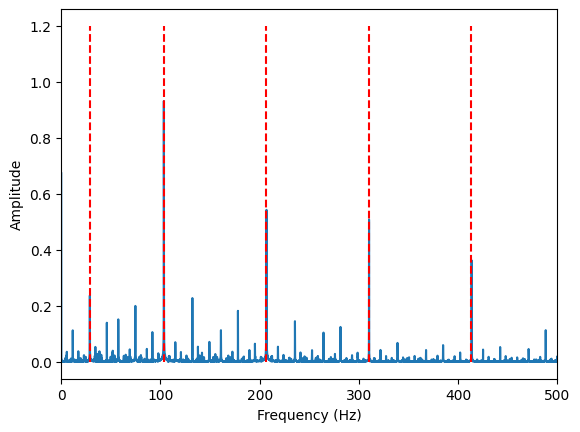

In [ ]:
path = os.getcwd() # Current working directory path
mat_file = os.path.join(path, "data", "exercise_data", "133.mat") # Path to the .mat file containing the signal data
data = scipy.io.loadmat(mat_file) # Load the .mat file data into a Python variable
keys = data.keys() # Get the keys of the loaded data
De_key = next((key for key in keys if "DE" in key), None) # Find the key that contains "DE"
signal = data[De_key].flatten() if De_key else None # Extract the signal data

# Your code begins here. Expected amount of code: 4-6 lines
fs = 12e3
sq_env_f, sq_env = envelope(signal, fs)
plt.plot(sq_env_f, sq_env)
plt.xlim((0, 500))
plt.vlines([f_r, BPFO_Hz, 2 * BPFO_Hz, 3 * BPFO_Hz, 4 * BPFO_Hz], ymin=0, ymax=1.2 , colors="r", linestyles="dashed")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()
# Your code ends here

## Part 3 Bearing fault analysis case study (Polito Data-set)

## Sources
[1] Chenyu Liu, Alexandre Mauricio, Junyu Qi, Dandan Peng, and Konstantinos
Gryllias. Domain Adaptation Digital Twin for Rolling Element Bearing Prog-
nostics. Annual Conference of the PHM Society, 12(1):10, November 2020.
doi:10.36001/phmconf.2020.v12i1.1294.